In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. The model

In [31]:
import numpy as np
from Python_module import ConsumerClass

# a. both calibrations, kept in one dictionary so we can loop over them
#    together in every later assignment instead of writing everything twice
models = {
    'Complements': ConsumerClass(),
    'Substitutes': ConsumerClass(par={'sigma_B': 3.00}),
}

# b. print both, to check the parameters really are what we expect
for name, model in models.items():
    print(name)
    print(model)
    print()

Complements
ConsumerClass
  alpha = 0.60, beta = 0.50
  sigma_A = 0.80, sigma_B = 0.40
  p1 = 1.00, p2 = 1.00, p3 = 1.50, I = 10.00

Substitutes
ConsumerClass
  alpha = 0.60, beta = 0.50
  sigma_A = 0.80, sigma_B = 3.00
  p1 = 1.00, p2 = 1.00, p3 = 1.50, I = 10.00



Both printouts match the calibration table above, and sigma_B is the only parameter that differs between them, so the two calibrations are set up correctly, and par={'sigma_B':3.0} really did only change that one number.

### 1.2 Testing .utility()

Before trusting .utility(), we check it on bundles we can reason about by hand, without needing to solve anything:

If $x_1=x_2=x_3=1$, both nests reduce to a weighted average of two identical numbers, so utility should come out at exactly $1$, whatever the weights and elasticities are.
Getting *more* of one good, holding the others fixed, should never lower utility.

In [32]:
# a. check 1: equal quantities should give utility of exactly 1
for name, model in models.items():
    u = model.utility(1.0, 1.0, 1.0)
    print(f'{name}: u(1,1,1) = {u:.4f}')

print()

# b. check 2: more food should not make the consumer worse off
model = models['Complements']
u_base = model.utility(1.0, 1.0, 1.0)
u_more_food = model.utility(2.0, 1.0, 1.0)
print(f'u(1,1,1) = {u_base:.4f}')
print(f'u(2,1,1) = {u_more_food:.4f}')
print(f'more food increases utility: {u_more_food > u_base}')

Complements: u(1,1,1) = 1.0000
Substitutes: u(1,1,1) = 1.0000

u(1,1,1) = 1.0000
u(2,1,1) = 1.4938
more food increases utility: True


Both checks come out the way they should: utility is exactly $1$ in the equal bundle for both calibrations, and doubling the food quantity raises utility. .utility()X looks correctly specified.

### 1.3 From nested shares to quantities

.shares(s1,w) turns a choice of $(s_1,w)$ into the three budget shares (eq. 3 in the assignment), and .quantities(s1,w) turns those into the actual quantities $x_1,x_2,x_3$, using the prices and income in par. We try this out at five points: the middle of the square and its four corners, points we will come back to in the next assignment, to start the optimizer from several different places.

In [33]:
# a. the points we will keep re-using in later assignments
points = {
    'middle': (0.5, 0.5),
    'corner (0,0)': (0.0, 0.0),
    'corner (0,1)': (0.0, 1.0),
    'corner (1,0)': (1.0, 0.0),
    'corner (1,1)': (1.0, 1.0),
}

model = models['Complements']

for name, (s1, w) in points.items():
    s1_share, s2, s3 = model.shares(s1, w)
    x1, x2, x3 = model.quantities(s1, w)
    total = s1_share + s2 + s3
    print(f'{name:>13}: shares=({s1_share:.2f},{s2:.2f},{s3:.2f}) sum={total:.2f}  '
          f'quantities=({x1:.2f},{x2:.2f},{x3:.2f})')

       middle: shares=(0.50,0.25,0.25) sum=1.00  quantities=(5.00,2.50,1.67)
 corner (0,0): shares=(0.00,0.00,1.00) sum=1.00  quantities=(0.00,0.00,6.67)
 corner (0,1): shares=(0.00,1.00,0.00) sum=1.00  quantities=(0.00,10.00,0.00)
 corner (1,0): shares=(1.00,0.00,0.00) sum=1.00  quantities=(10.00,0.00,0.00)
 corner (1,1): shares=(1.00,0.00,0.00) sum=1.00  quantities=(10.00,0.00,0.00)


The three shares sum to 1 at every point, exactly as the reparametrization promises, and every quantity comes out non-negative. A corner just means "spend nothing" on one or two goods (e.g. corner (0,1) spends the whole budget on food, so both travel quantities are zero, not negative or undefined).

One thing is worth noticing: corners (1,0) and (1,1) give the 'same' shares. That makes sense once we think about it, $s_1=1$ already spends the entire income on food, so there is no travel budget left, and $w$ (the split of a budget of *zero*) stops mattering. Good to keep in mind before the next assignment searches this square for the best point.

### 1.4 shares straight to utility
Here we calculate the choice of $(s_1,w)$ directly as a utility number. We do this because it is exactly the function the optimizer will be handed in the next assignment, so it is worth checking now that it agrees with calling .quantities() and .utility() seperately, one after another.

In [34]:
s1, w = 0.5, 0.5

for name, model in models.items():

    # a. the two-step way
    x1, x2, x3 = model.quantities(s1, w)
    u_manual = model.utility(x1, x2, x3)

    # b. the shortcut
    u_direct = model.value_of_choice(s1, w)

    print(f'{name}: manual = {u_manual:.6f}, value_of_choice = {u_direct:.6f}, '
          f'agree = {np.isclose(u_manual, u_direct)}')

Complements: manual = 3.363085, value_of_choice = 3.363085, agree = True
Substitutes: manual = 3.431165, value_of_choice = 3.431165, agree = True


They agree exactly, as they should. Using the shortcut does nothing but call the other two methods in order.

Notice also that at the same point (s_1,w)=(0.5,0.5), the two calibrations already give different utility levels. That does not yet tell us which (s_1,w) is 'best' for either consumer, only that the model reacts to $\sigma_B$. Finding the best point once with a grid search, and once with scipy.optimize.minimize.

## 2. Solving the model numerically

Now we  solve the model: once with a brute-force grid search, once with the scipy.optimize.minimize command mentioned in the assignment (L-BFGS-B).

### 2.1 Grid search

.solve_grid(N) checks utility at every point of an $N\times N$ grid over $(s_1,w)$ and keeps the best one.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# a. solve both calibrations by grid search, and keep the results for plotting
grid_results = {name: model.solve_grid(N=200) for name, model in models.items()}

grid search, N = 200: (s1,w) = (0.5377,0.4372), u = 3.4016, evaluations = 40000
grid search, N = 200: (s1,w) = (0.5377,0.6935), u = 3.4851, evaluations = 40000


#### 2.1.2

Both solutions are interior points, and Substitutes puts more of the travel budget on the bus (higher $w$), since bus and train substitute freely there, the consumer tilts hard towards the cheaper one. Plotted below, as a 3D surface and a contour, with the solution marked:

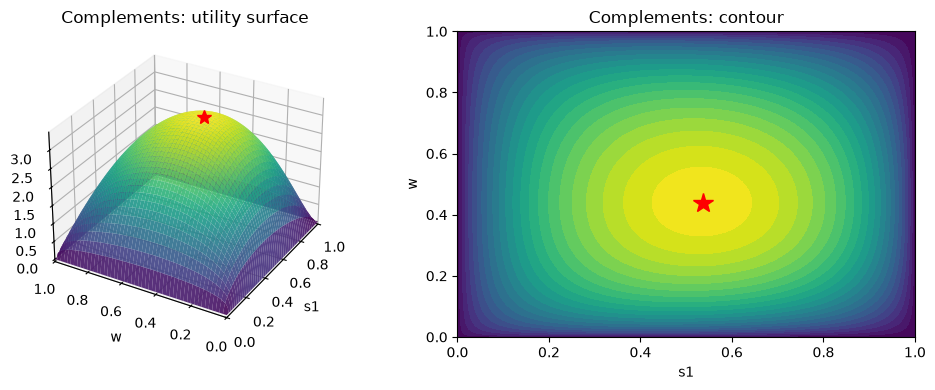

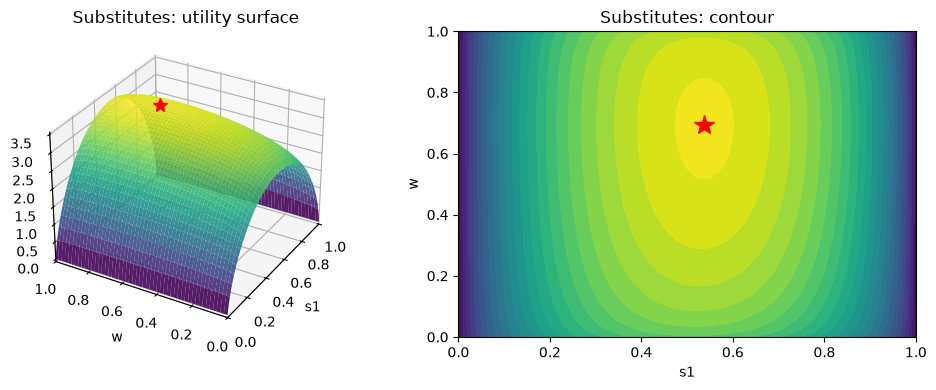

In [36]:
for name, opt in grid_results.items():
    fig = plt.figure(figsize=(10, 4))

    # a. utility surface, with the solution marked
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_surface(opt.s1_grid, opt.w_grid, opt.u_grid, cmap='viridis', alpha=0.9)
    ax.plot([opt.s1], [opt.w], [opt.u], marker='*', color='red', markersize=10, zorder=10)
    ax.set_xlim(opt.s1_grid.min(), opt.s1_grid.max())
    ax.set_ylim(opt.w_grid.min(), opt.w_grid.max())
    ax.view_init(elev=30, azim=210)  # rotate so (0,0) is the front corner, not (s1=1, w=0)
    ax.set_xlabel('s1'); ax.set_ylabel('w'); ax.set_zlabel('u')
    ax.set_title(f'{name}: utility surface')

    # b. contour, with the solution marked
    ax = fig.add_subplot(1, 2, 2)
    ax.contourf(opt.s1_grid, opt.w_grid, opt.u_grid, levels=30, cmap='viridis')
    ax.plot(opt.s1, opt.w, 'r*', markersize=15)
    ax.set_xlim(opt.s1_grid.min(), opt.s1_grid.max())
    ax.set_ylim(opt.w_grid.min(), opt.w_grid.max())
    ax.set_xlabel('s1'); ax.set_ylabel('w')
    ax.set_title(f'{name}: contour')

    plt.tight_layout()
    plt.show()

We test how much $N$ matters. We try $N=50,100,500,1000$:

In [37]:
rows = []
for name, model in models.items():
    for N in [50, 100, 500, 1000]:
        opt = model.solve_grid(N=N, do_print=False)
        rows.append({'calibration': name, 'N': N, 's1': opt.s1, 'w': opt.w, 'u': opt.u, 'evaluations': N*N})

pd.DataFrame(rows).round(4)

,calibration,N,s1,w,u,evaluations
0,Complements,50,0.5306,0.4490,3.4007,2500
1,Complements,100,0.5354,0.4444,3.4015,10000
2,Complements,500,0.5351,0.4389,3.4017,250000
3,Complements,1000,0.5355,0.4394,3.4017,1000000
4,Substitutes,50,0.5306,0.6939,3.4846,2500
5,Substitutes,100,0.5354,0.6970,3.4850,10000
6,Substitutes,500,0.5391,0.6914,3.4851,250000
7,Substitutes,1000,0.5385,0.6927,3.4851,1000000


In [38]:
# how much sharper is the peak in one calibration than the other?
for name, opt in grid_results.items():
    frac_near_top = np.mean(opt.u_grid > 0.99 * opt.u_grid.max())
    print(f'{name}: {frac_near_top*100:.1f}% of grid points are within 1% of the best utility')

Complements: 1.3% of grid points are within 1% of the best utility
Substitutes: 3.2% of grid points are within 1% of the best utility


#### 2.1.3 
Going from $N=50$ to $N=1000$ only moves $(s_1,w)$ in the 3rd decimal, but costs 400 times more evaluations ($50^2$ vs. $1000^2$), most of the improvement already happens by $N=100$. It improves smoothly, with no jumps.

#### 2.1.4 
At $N=200$, only 1.3% of grid points land within 1% of the best utility in complements, against 3.2% in substitutes, so complements has a sharper, narrower peak, and turns out to be the harder one for an optimizer (see 2.2.3 below).

### 2.2 L-BFGS-B

Here we use .solve() to call  scipy.optimize.minimize with method='L-BFGS-B' and bounds $((0,1),(0,1))$. 

In [39]:
import time

# a. solve both calibrations, and compare with the grid search (N=1000, our most precise one)
rows = []
for name, model in models.items():
    t0 = time.perf_counter(); grid = model.solve_grid(N=1000, do_print=False); t1 = time.perf_counter()
    t2 = time.perf_counter(); lbfgsb = model.solve(do_print=False); t3 = time.perf_counter()
    rows.append({'calibration': name, 'method': 'grid (N=1000)', 's1': grid.s1, 'w': grid.w, 'u': grid.u,
                 'evaluations': 1_000_000, 'time_ms': (t1-t0)*1000})
    rows.append({'calibration': name, 'method': 'L-BFGS-B', 's1': lbfgsb.s1, 'w': lbfgsb.w, 'u': lbfgsb.u,
                 'evaluations': lbfgsb.res.nfev, 'time_ms': (t3-t2)*1000})

pd.DataFrame(rows).round(4)

,calibration,method,s1,w,u,evaluations,time_ms
0,Complements,grid (N=1000),0.5355,0.4394,3.4017,1000000,187.3498
1,Complements,L-BFGS-B,0.5356,0.4395,3.4017,18,14.1152
2,Substitutes,grid (N=1000),0.5385,0.6927,3.4851,1000000,191.3616
3,Substitutes,L-BFGS-B,0.5382,0.6923,3.4851,27,4.2777


They agree to about 4 decimals, but L-BFGS-B gets there with a few dozen evaluations instead of a million. And is much faster.

**2.2.2 The convergence path.** We track it with a callback, starting from corner $(0,0)$, and draw it on top of the contour:

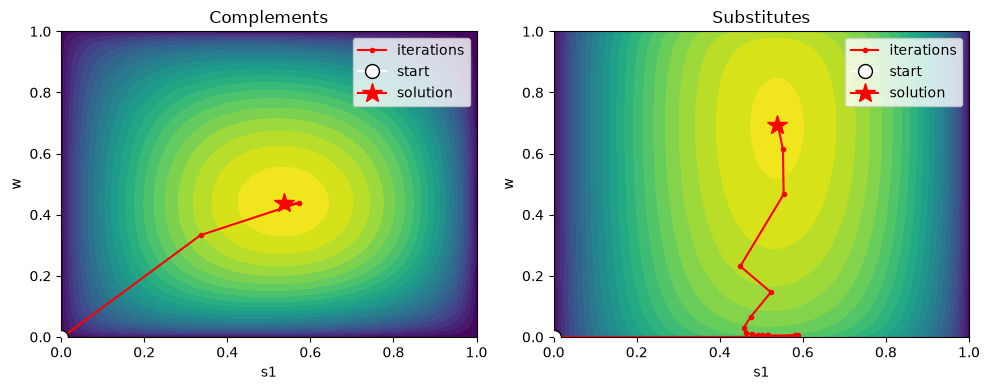

In [58]:
paths = {name: model.solve(s0=np.array([0.0, 0.0]), do_print=False) for name, model in models.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, opt) in zip(axes, paths.items()):
    grid = grid_results[name]
    ax.contourf(grid.s1_grid, grid.w_grid, grid.u_grid, levels=30, cmap='viridis')
    ax.plot(opt.path[:, 0], opt.path[:, 1], 'r.-', label='iterations')
    ax.plot(opt.path[0, 0], opt.path[0, 1], marker='o', color='white', markeredgecolor='black', markersize=10, zorder=10, label='start')
    ax.plot(opt.path[-1, 0], opt.path[-1, 1], marker='*', color='red', markersize=15, zorder=10, label='solution')
    ax.set_xlabel('s1'); ax.set_ylabel('w'); ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

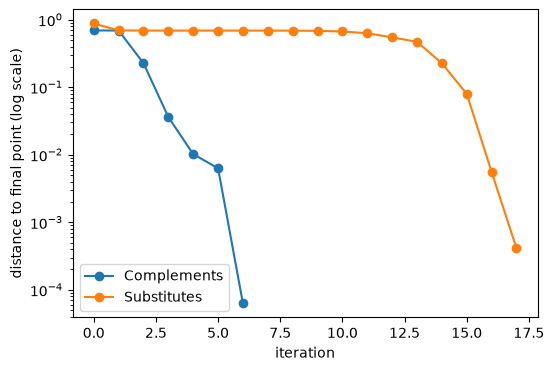

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, opt in paths.items():
    dist_to_final = np.linalg.norm(opt.path - opt.path[-1], axis=1)
    ax.semilogy(dist_to_final[:-1], marker='o', label=name)  # drop the last point: distance 0

ax.set_xlabel('iteration')
ax.set_ylabel('distance to final point (log scale)')
ax.legend()
plt.show()

The two calibrations look quite different here. Complements makes almost all of its progress in a couple of big steps around iteration 2-6. Substitutes barely moves for its first eleven iterations, matching the path plot above, where it creeps along the $w=0$ edge. Before it finally corrects sharply in its last few steps.

**2.2.3 Does the starting point matter?** We try six: the middle, all four corners, and one extra interior point.

In [14]:
starts = {
    'middle': (0.5, 0.5),
    'corner (0,0)': (0.0, 0.0),
    'corner (0,1)': (0.0, 1.0),
    'corner (1,0)': (1.0, 0.0),
    'corner (1,1)': (1.0, 1.0),
    'interior (0.2,0.8)': (0.2, 0.8),
}

rows = []
for name, model in models.items():
    for s_name, s0 in starts.items():
        opt = model.solve(s0=np.array(s0), do_print=False)
        rows.append({'calibration': name, 'start': s_name, 's1': opt.s1, 'w': opt.w, 'u': opt.u,
                     'iterations': opt.res.nit, 'success': opt.res.success})

pd.DataFrame(rows).round(4)

,calibration,start,s1,w,u,iterations,success
0,Complements,middle,0.5356,0.4395,3.4017,4,True
1,Complements,"corner (0,0)",0.5356,0.4395,3.4017,7,True
2,Complements,"corner (0,1)",0.5356,0.4395,3.4017,9,True
3,Complements,"corner (1,0)",1.0000,0.0000,0.0000,1,True
4,Complements,"corner (1,1)",1.0000,1.0000,0.0000,1,True
5,Complements,"interior (0.2,0.8)",0.5356,0.4395,3.4017,6,True
6,Substitutes,middle,0.5382,0.6923,3.4851,6,True
7,Substitutes,"corner (0,0)",0.5382,0.6923,3.4851,18,True
8,Substitutes,"corner (0,1)",0.5382,0.6923,3.4851,17,True
9,Substitutes,"corner (1,0)",0.5382,0.6923,3.4851,18,True


Every starting point finds the same answer. Except for two, in Complements: starting exactly at corner (1,0) or (1,1), the solver stops after a single iteration reporting success = True, at $u\approx0$. That is the worst point in the square, not the best.

Here is why: at $s_1=1$ there is no travel budget left, so bus and train are both (essentially) zero, and since $\sigma_A,\sigma_B<1$ in this calibration the consumer cannot substitute food for travel at all -- utility collapses towards zero right at that boundary ($u=0.01$ already at $s_1=0.9999$). It falls so fast that the gradient computed *exactly at* the corner is only about $10^{-14}$ -- far below the threshold L-BFGS-B uses to decide it has converged -- so it stops immediately, fooled into thinking it has already found the optimum. Starting just $0.0001$ away from the corner is enough to fix it.

**2.2.4 tolerance settings.** Varying ftol and gtol (holding the other at its default), for both calibrations:

In [15]:
rows = []
for name, model in models.items():
    for ftol in [1e-4, 1e-8, 1e-12, 1e-16]:
        opt = model.solve(do_print=False, options={'ftol': ftol})
        rows.append({'calibration': name, 'setting': f'ftol={ftol:.0e}', 's1': opt.s1, 'w': opt.w,
                     'u': opt.u, 'evaluations': opt.res.nfev})
    for gtol in [1e-2, 1e-5, 1e-8, 1e-12]:
        opt = model.solve(do_print=False, options={'gtol': gtol})
        rows.append({'calibration': name, 'setting': f'gtol={gtol:.0e}', 's1': opt.s1, 'w': opt.w,
                     'u': opt.u, 'evaluations': opt.res.nfev})

pd.DataFrame(rows).round(6)

,calibration,setting,s1,w,u,evaluations
0,Complements,ftol=1e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol=1e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol=1e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol=1e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol=1e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol=1e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol=1e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol=1e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol=1e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol=1e-08,0.538225,0.692308,3.485105,27


**2.2.5** Past roughly 1e-8, tightening either setting further changes nothing. Same answer, same number of evaluations because floating-point arithmetic already can't tell the objective apart at that precision. The loosest settings (ftol=1e-4, gtol=1e-2) trade away a little precision for slightly fewer evaluations.

We would use the defaults (around ftol=1e-8, gtol=1e-5): tight enough to reach the best answer floating point allows, without paying for evaluations a tighter tolerance can't actually use here. A tighter tolerance is not automatically better, because past that point there is nothing left to gain -- you are just asking the solver to keep splitting hairs it cannot feel.

Next assignment: how demand responds as the price of a train ticket rises.

## 3. Relative prices and demand

Train tickets get more expensive: we solve the model for $p_3$ from 0.5 to 3.0 (holding $p_1$, $p_2$ and $I$ fixed) and see what the consumer does, in both calibrations.

In [17]:
# a. the calibrations, re-using each model's sigma_B so we don't retype it
sigma_B = {name: model.par.sigma_B for name, model in models.items()}

# b. solve the model at every p3, for both calibrations, and collect the results
p3_vec = np.linspace(0.5, 3.0, 50)

rows = []
for name, sB in sigma_B.items():
    for p3 in p3_vec:
        model = ConsumerClass(par={'sigma_B': sB, 'p3': p3})
        opt = model.solve(do_print=False)
        x1, x2, x3 = model.quantities(opt.s1, opt.w)
        rows.append({'calibration': name, 'p3': p3, 's1': opt.s1, 's2': opt.s2, 's3': opt.s3,
                     'x1': x1, 'x2': x2, 'x3': x3})

df = pd.DataFrame(rows)
df.head()

,calibration,p3,s1,s2,s3,x1,x2,x3
0,Complements,0.500000,0.561660,0.264099,0.174241,5.616601,2.640994,3.484810
1,Complements,0.551020,0.559724,0.259084,0.181193,5.597238,2.590836,3.288310
2,Complements,0.602041,0.557899,0.254443,0.187658,5.578987,2.544434,3.117029
3,Complements,0.653061,0.556171,0.250127,0.193702,5.561707,2.501274,2.966059
4,Complements,0.704082,0.554528,0.246094,0.199377,5.545283,2.460944,2.831736


Budget shares first, then quantities:

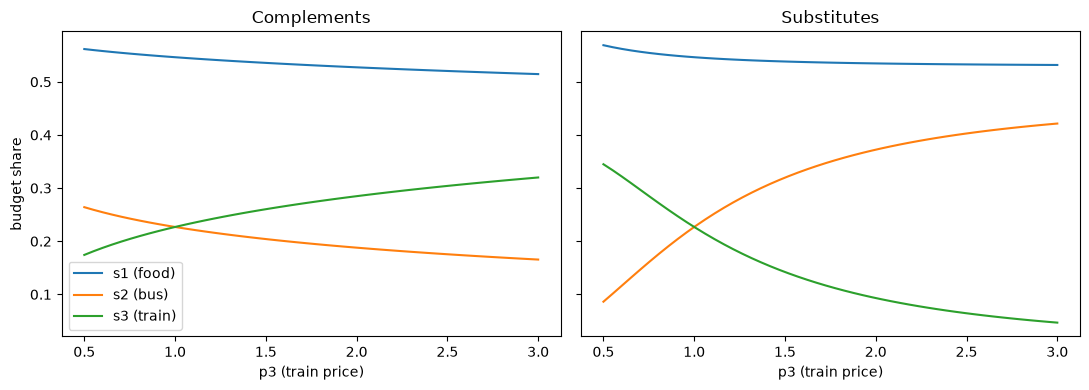

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, sigma_B):
    d = df[df.calibration == name]
    ax.plot(d.p3, d.s1, label='s1 (food)')
    ax.plot(d.p3, d.s2, label='s2 (bus)')
    ax.plot(d.p3, d.s3, label='s3 (train)')
    ax.set_xlabel('p3 (train price)')
    ax.set_title(name)

axes[0].set_ylabel('budget share')
axes[0].legend()
plt.tight_layout()
plt.show()

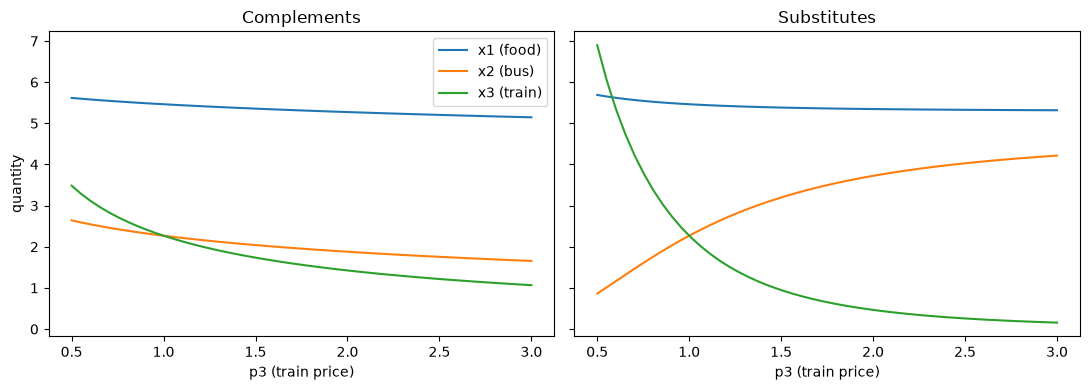

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, sigma_B):
    d = df[df.calibration == name]
    ax.plot(d.p3, d.x1, label='x1 (food)')
    ax.plot(d.p3, d.x2, label='x2 (bus)')
    ax.plot(d.p3, d.x3, label='x3 (train)')
    ax.set_xlabel('p3 (train price)')
    ax.set_title(name)

axes[0].set_ylabel('quantity')
axes[0].legend()
plt.tight_layout()
plt.show()

A short summary, comparing the two ends of the price range:

In [20]:
rows = []
for name in sigma_B:
    d = df[df.calibration == name]
    rows.append({
        'calibration': name,
        's3 @ p3=0.5': d.s3.iloc[0], 's3 @ p3=3.0': d.s3.iloc[-1],
        'x1 % change': 100*(d.x1.iloc[-1]/d.x1.iloc[0] - 1),
        'x2 % change': 100*(d.x2.iloc[-1]/d.x2.iloc[0] - 1),
        'x3 % change': 100*(d.x3.iloc[-1]/d.x3.iloc[0] - 1),
    })

pd.DataFrame(rows).round(2)

,calibration,s3 @ p3=0.5,s3 @ p3=3.0,x1 % change,x2 % change,x3 % change
0,Complements,0.17,0.32,-8.39,-37.33,-69.39
1,Substitutes,0.34,0.05,-6.54,388.83,-97.74


**3.2 -- train's budget share.** It rises in Complements (0.17 to 0.32) and falls in Substitutes (0.34 to 0.05): unable to substitute away, the Complements consumer keeps buying almost as much train even as it gets pricier, so spending on it grows; the Substitutes consumer flees to the bus instead, so spending on train collapses.

**3.3 -- bus trips.** They move *with* train in Complements (-37%: bus and train are used together, so cutting train means cutting bus too) and *against* it in Substitutes (+389%: bus absorbs the trips train loses).

**3.4 -- food demand.** Food barely reacts either way (-8.4% / -6.5%) -- it sits outside the travel nest, so it is mostly shielded from what happens between bus and train. Bus reacts about 4x more than food in Complements, and in Substitutes it does not just react more (+389%) -- it moves in the opposite direction entirely.